# **Machine Learning Assignment :- 6**

**   **
**Name: Harish Panpaliya**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 52**

**PRN: 12412173**

Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:

 a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

 b. Bivariate analysis: Linear and logistic regression modeling

 c. Multiple Regression analysis

 d. Also compare the results of the above analysis for the two data sets. Dataset link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

# Imported Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv('diabetes.csv')

df = df.iloc[:, 1:]

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)
df = df.dropna()

df.to_csv('cleaned_diabetes.csv', index=False)

In [ ]:
dp = pd.read_csv('cleaned_diabetes.csv')
dp

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,189.0,60.0,23.0,846.0,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...
387,181.0,88.0,44.0,510.0,43.3,0.222,26,1
388,128.0,88.0,39.0,110.0,36.5,1.057,37,1
389,88.0,58.0,26.0,16.0,28.4,0.766,22,0
390,101.0,76.0,48.0,180.0,32.9,0.171,63,0


In [ ]:
dp.shape

(392, 8)

In [ ]:
dp.describe()


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## corelation check

In [ ]:
corelation_check = dp.corr()

print(corelation_check)


# print("\nCorrelation with Outcome:")
# print(df.corr()['Outcome'].sort_values(ascending=False))

                           Glucose  BloodPressure  SkinThickness   Insulin  \
Glucose                   1.000000       0.210027       0.198856  0.581223   
BloodPressure             0.210027       1.000000       0.232571  0.098512   
SkinThickness             0.198856       0.232571       1.000000  0.182199   
Insulin                   0.581223       0.098512       0.182199  1.000000   
BMI                       0.209516       0.304403       0.664355  0.226397   
DiabetesPedigreeFunction  0.140180      -0.015971       0.160499  0.135906   
Age                       0.343641       0.300039       0.167761  0.217082   
Outcome                   0.515703       0.192673       0.255936  0.301429   

                               BMI  DiabetesPedigreeFunction       Age  \
Glucose                   0.209516                  0.140180  0.343641   
BloodPressure             0.304403                 -0.015971  0.300039   
SkinThickness             0.664355                  0.160499  0.167761   
I

In [ ]:
#Frequency of outcome column
dp['Outcome'].value_counts()

,count
Outcome,
0,262
1,130


## calculate statistical summary

In [ ]:
from scipy.stats import skew,kurtosis

uni = pd.DataFrame({
    "Mean": dp.mean(),
    "Median": dp.median(),
    "Mode": dp.mode().iloc[0],
    "Variance": dp.var(),
    "Std_Dev": dp.std(),
    "Skewness": dp.apply(skew),
    "Kurtosis": dp.apply(kurtosis)
})

print("Univariate Statistics Summary")
display(uni)

Univariate Statistics Summary


,Mean,Median,Mode,Variance,Std_Dev,Skewness,Kurtosis
Glucose,122.627551,119.0000,100.000,952.387781,30.860781,0.515866,-0.492353
BloodPressure,70.663265,70.0000,70.000,156.152304,12.496092,-0.087181,0.770028
SkinThickness,29.145408,29.0000,32.000,110.595171,10.516424,0.208509,-0.467146
Insulin,156.056122,125.5000,105.000,14123.347226,118.841690,2.156822,6.260449
BMI,33.086224,33.2000,32.000,49.387994,7.027659,0.660944,1.521463
DiabetesPedigreeFunction,0.523046,0.4495,0.692,0.119362,0.345488,1.951597,6.270504
Age,30.864796,27.0000,22.000,104.055842,10.200777,1.398230,1.700180
Outcome,0.331633,0.0000,0.000,0.222219,0.471401,0.715240,-1.488432


## Frequency comparison

Frequency of Diabetic vs Non-Diabetic Cases:
Outcome
0    262
1    130
Name: count, dtype: int64


/tmp/ipykernel_2702/759889634.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=dp, palette='viridis')


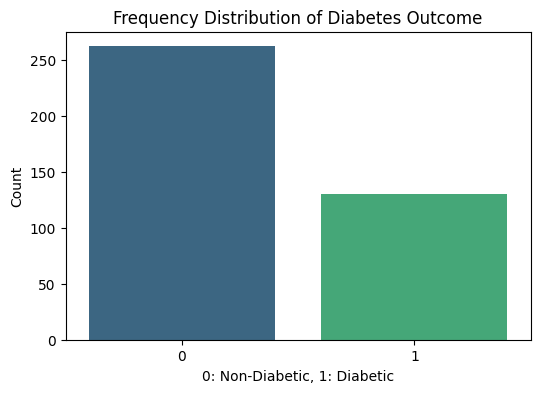

In [ ]:
# # Frequency Analysis of Outcome
# print("Frequency of Diabetic vs Non-Diabetic Cases:")
# print(dp['Outcome'].value_counts())

# plt.figure(figsize=(6, 4))
# sns.countplot(x='Outcome', data=dp, palette='viridis')
# plt.title('Frequency Distribution of Diabetes Outcome')
# plt.xlabel('0: Non-Diabetic, 1: Diabetic')
# plt.ylabel('Count')
# plt.show()



import seaborn as sns  # This defines 'sns' to fix your error
import matplotlib.pyplot as plt

# Frequency Analysis of Outcome
print("Frequency of Diabetic vs Non-Diabetic Cases:")
print(dp['Outcome'].value_counts())

plt.figure(figsize=(6, 4))
# Now sns.countplot will work perfectly
sns.countplot(x='Outcome', data=dp, palette='viridis')
plt.title('Frequency Distribution of Diabetes Outcome')
plt.xlabel('0: Non-Diabetic, 1: Diabetic')
plt.ylabel('Count')
plt.show()

## Single feature Linear regression

In [ ]:
X = dp[['Glucose']]   # Single feature
y = dp[['Insulin']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print("Linear Regression Results (Sklearn Dataset)")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Linear Regression Results (Sklearn Dataset)
Coefficient: [[2.23986883]]
Intercept: [-116.25794942]
R2 Score: 0.38123642952556447
MSE: 7877.785642299832


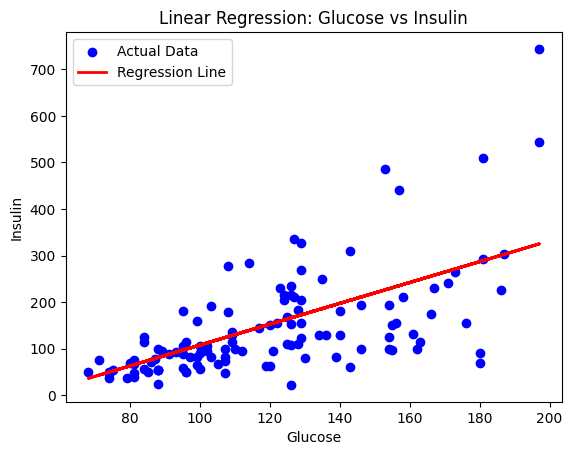

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.scatter(X_test, y_test, color='blue', label='Actual Data')


plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.title('Linear Regression: Glucose vs Insulin')
plt.legend()
plt.show()

## Logistic Regression

In [ ]:
## --- SECTION: Bivariate Analysis (Logistic Regression) ---
from sklearn.linear_model import LogisticRegression

# Using Glucose to predict the Outcome (Diabetes or not)
X_log = dp[['Glucose']]
y_log = dp['Outcome']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.3, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train_l, y_train_l)
y_pred_log = log_model.predict(X_test_l)

print("Logistic Regression (Glucose vs Outcome):")
print("Accuracy Score:", accuracy_score(y_test_l, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_l, y_pred_log))

Logistic Regression (Glucose vs Outcome):
Accuracy Score: 0.7203389830508474
Confusion Matrix:
 [[68 12]
 [21 17]]


## Multi feature Linear Regression

In [ ]:
## --- SECTION: Multiple Regression Analysis ---
# Predicting Insulin using three features: Glucose, BMI, and Age
X_multi = dp[['Glucose', 'BMI', 'Age']]
y_multi = dp['Insulin']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_m = multi_model.predict(X_test_m)

print("Multiple Regression Results (Predicting Insulin):")
print("R2 Score:", r2_score(y_test_m, y_pred_m))
print("MSE:", mean_squared_error(y_test_m, y_pred_m))

Multiple Regression Results (Predicting Insulin):
R2 Score: 0.38327114797881334
MSE: 7851.880633372372


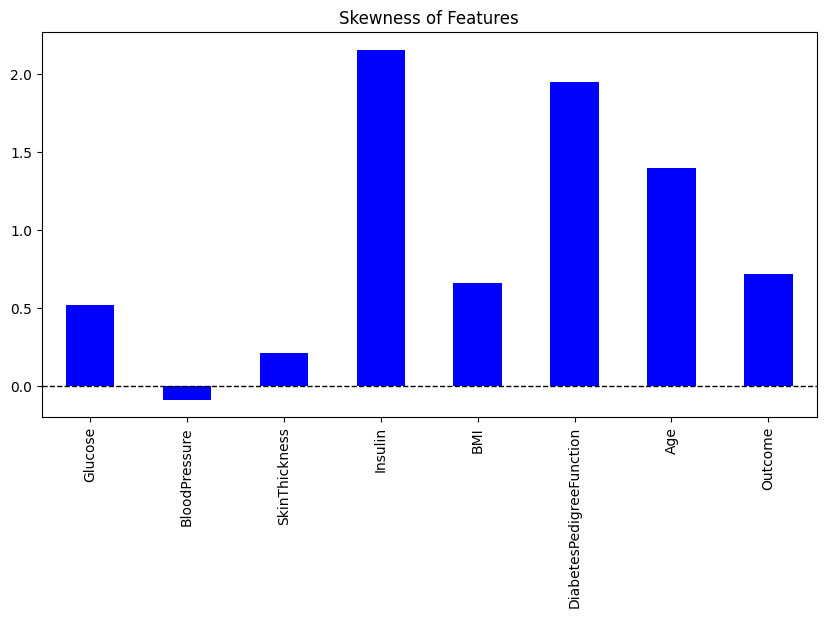

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# skewness in uni
plt.figure(figsize=(10, 5))
uni['Skewness'].plot(kind='bar', color='blue')
plt.title('Skewness of Features')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()


## Skewness curves

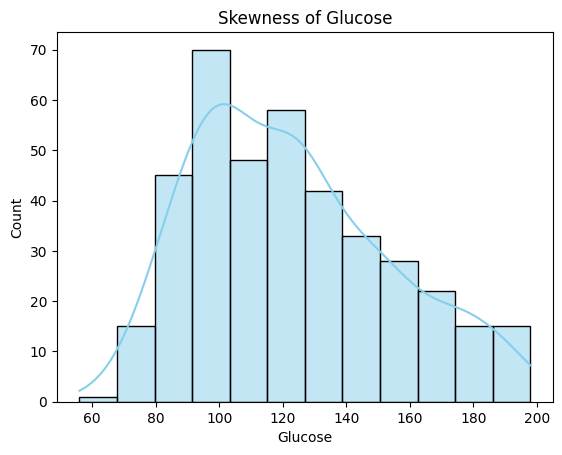

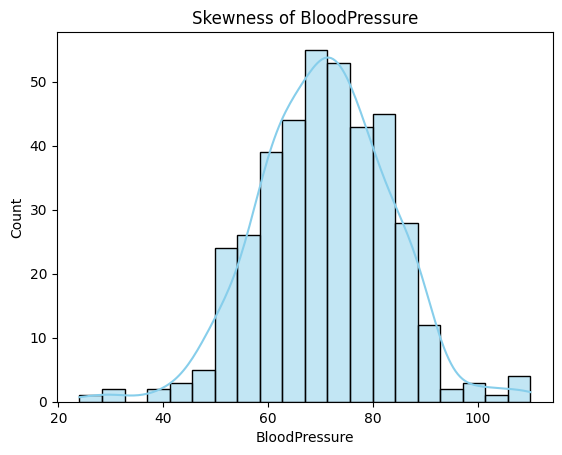

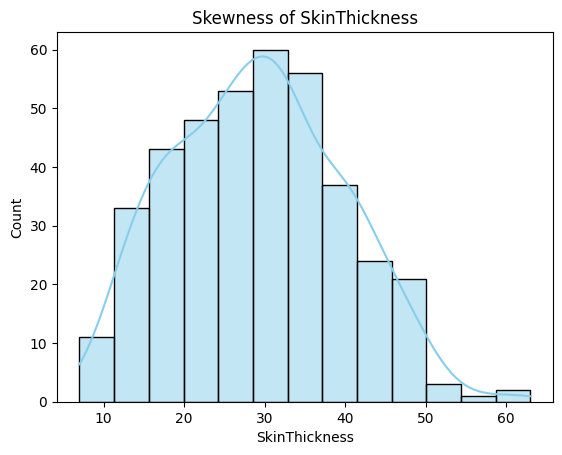

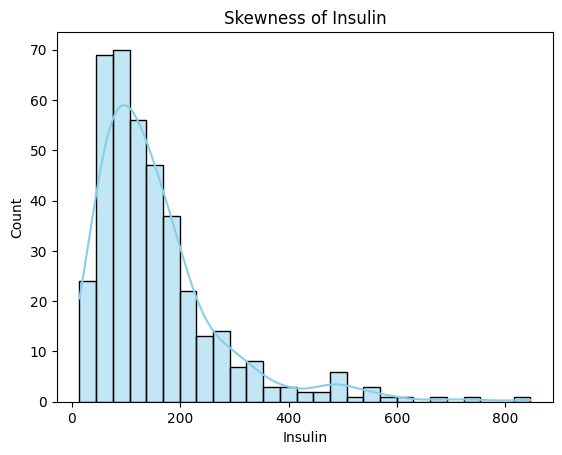

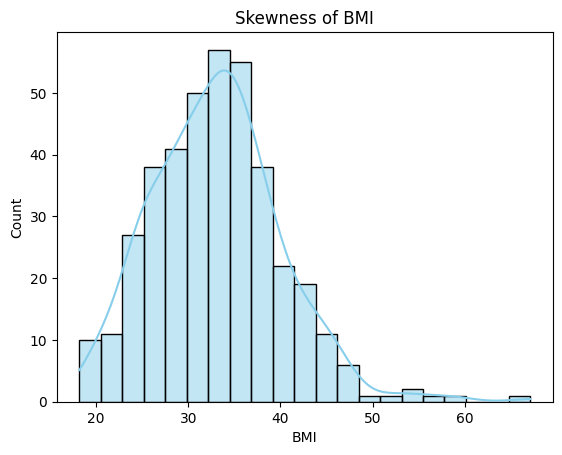

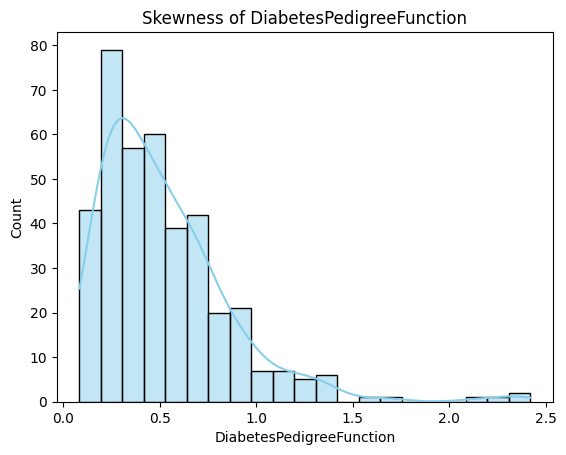

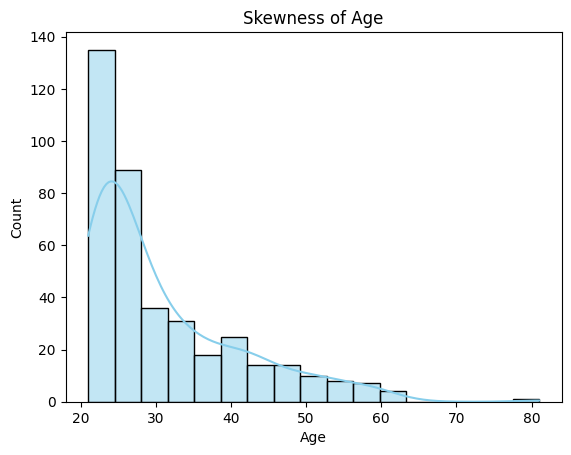

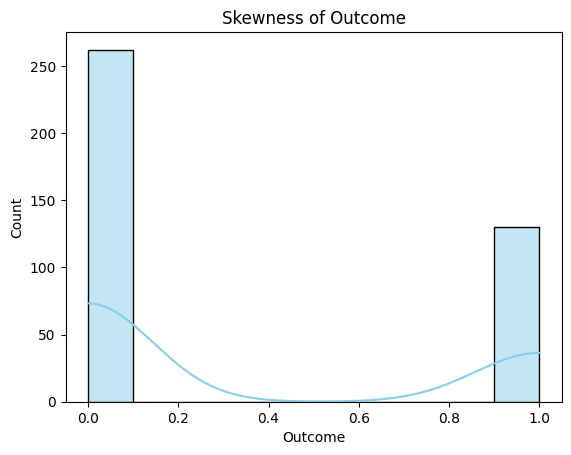

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in dp.columns:
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Skewness of {col}')
    plt.show()

In [ ]:
X = dp[['Glucose']]   # Single feature
y = dp['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Logistic Regression Results (diabetes Dataset)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Results (diabetes Dataset)
Accuracy: 0.7203389830508474
Confusion Matrix:
 [[68 12]
 [21 17]]


In [ ]:
X = dp[['DiabetesPedigreeFunction']]   # Single feature
y = dp['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Logistic Regression Results (diabetes Dataset)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Results (diabetes Dataset)
Accuracy: 0.7033898305084746
Confusion Matrix:
 [[79  1]
 [34  4]]
